# 1er Parcial - Clasificacion binaria

**Pregunta:** si tengo un mal rendimiento en el primer parcial, puedo remontar en el segundo?

**Dataset:** `datos/rendimiento_anho_2025_ciclo_1_anon.xlsx` (ciclo 1, 2025)

| | |
|---|---|
| Entrada (X) | `Primer.Par` -> puntaje del primer parcial, sobre 100 |
| Salida (y)  | `Aprobado` -> 1 = pasa la materia, 0 = no pasa |
| Uso final   | el usuario escribe su puntaje y el modelo responde PASA / NO PASA |

**Modelos comparados**
1. Regresion logistica con regularizacion **Elastic-Net** (`sklearn`)
2. **SVM lineal**
3. **SVM RBF**

Separacion de datos: **80% entrenamiento / 20% test**, estratificada.


In [16]:
#················ importaciones de librerias ···················#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
)

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)

# diccionarios donde cada modelo va dejando sus metricas (se usan en la seccion 6)
resultados = {}
modelos = {}

print("Librerias cargadas OK")

Librerias cargadas OK


In [17]:
# 1 ########### Carga de datos ############
RUTA = "datos/rendimiento_año_2025_ciclo_1_anon.xlsx"

df = pd.read_excel(RUTA)

print("Filas x columnas :", df.shape)
print("Alumnos unicos   :", df["ALUMNO_ID"].nunique())
print("Asignaturas      :", df["Asignatura"].nunique())
print()
print("Distribucion de la columna objetivo 'Aprobado':")
print(df["Aprobado"].value_counts())
print()
print("Estadisticas de 'Primer.Par':")
print(df["Primer.Par"].describe())

df[["ALUMNO_ID", "Asignatura", "Primer.Par", "Segundo.Par", "Aprobado"]].head(10)

Filas x columnas : (19407, 29)
Alumnos unicos   : 4000
Asignaturas      : 192

Distribucion de la columna objetivo 'Aprobado':
Aprobado
S    11633
N     7774
Name: count, dtype: int64

Estadisticas de 'Primer.Par':
count    19407.000000
mean        48.859278
std         31.985466
min          0.000000
25%         23.000000
50%         52.000000
75%         75.000000
max        100.000000
Name: Primer.Par, dtype: float64


,ALUMNO_ID,Asignatura,Primer.Par,Segundo.Par,Aprobado
0,FIUNA_ALUMNO_005168,FISICA 4,44,35,N
1,FIUNA_ALUMNO_007802,FISICA 4,44,35,N
2,FIUNA_ALUMNO_005236,FISICA 4,0,0,N
3,FIUNA_ALUMNO_007824,FISICA 4,0,0,N
4,FIUNA_ALUMNO_005531,FISICA 4,0,0,N
5,FIUNA_ALUMNO_007525,FISICA 4,0,0,N
6,FIUNA_ALUMNO_006379,FISICA 4,12,0,N
7,FIUNA_ALUMNO_006811,FISICA 4,12,0,N
8,FIUNA_ALUMNO_005963,FISICA 4,5,13,N
9,FIUNA_ALUMNO_007449,FISICA 4,5,13,N


In [18]:
# 2 ########## procesamiento de datos ############

# --- 2.1 Limpieza -----------------------------------------------------------
# Primer.Par == 0 NO significa "saco cero": en la mayoria de los casos es un
# alumno ausente / que no rindio el parcial. Mezclarlo con notas reales rompe
# la monotonia de la curva (de esas filas un 24.7% igual aprueba). Se excluyen.
datos = df[df["Primer.Par"] > 0].copy()

print("Filas originales :", len(df))
print("Filas descartadas (Primer.Par == 0):", len(df) - len(datos))
print("Filas utilizadas :", len(datos))

# Nota: hay filas duplicadas si se ignora ALUMNO_ID. Con un unico feature
# entero de 1 a 100 y 16k registros los valores repetidos son inevitables,
# no invalidan la separacion train/test.

# --- 2.2 Feature y target ---------------------------------------------------
X = datos[["Primer.Par"]].astype(float)      # entrada: puntaje sobre 100
y = (datos["Aprobado"] == "S").astype(int)   # salida : 1 = pasa, 0 = no pasa

# --- 2.3 Separacion 80% / 20% ----------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,             # mantiene la proporcion de clases en ambos splits
    random_state=RANDOM_STATE,
)

print()
print("Train:", X_train.shape[0], "filas | % que pasa:", round(y_train.mean() * 100, 2))
print("Test :", X_test.shape[0], "filas | % que pasa:", round(y_test.mean() * 100, 2))

# El StandardScaler se aplica DENTRO de un Pipeline en cada modelo, para que se
# ajuste solo con los datos de entrenamiento (evita fuga de datos hacia el test).

# --- 2.4 Datos escalados para los barridos de hiperparametros ---------------
# Los barridos de las secciones 4 y 5 trabajan con arrays ya escalados.
# Los modelos FINALES igual se arman como Pipeline (scaler + modelo), asi
# pueden recibir el puntaje crudo 0-100 al momento de predecir.
scaler_busqueda = StandardScaler().fit(X_train)
X_train_scaled = scaler_busqueda.transform(X_train)
X_test_scaled = scaler_busqueda.transform(X_test)

# Submuestra del train usada SOLO para el barrido. Sobre las 12897 filas
# completas las combinaciones con C y gamma grandes tardan varios minutos
# cada una (el costo de SVC crece de forma casi cuadratica con n), y la
# accuracy que se obtiene es la misma.
N_BUSQUEDA = 3000
_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(X_train_scaled), N_BUSQUEDA, replace=False)
X_busq, y_busq = X_train_scaled[_idx], y_train.iloc[_idx]

print()
print("Barrido de hiperparametros sobre una submuestra de", N_BUSQUEDA, "filas del train")

# --- 2.5 Grilla y utilidades comunes a los 3 modelos ------------------------
GRID = pd.DataFrame({"Primer.Par": np.linspace(1, 100, 500)})


def umbral_aprobacion(modelo):
    """Puntaje minimo de primer parcial a partir del cual el modelo predice PASA."""
    pred = modelo.predict(GRID)
    positivos = GRID["Primer.Par"].values[pred == 1]
    return round(float(positivos.min()), 1) if len(positivos) else np.nan


def evaluar(nombre, modelo, mostrar_reporte=True):
    """Calcula las metricas sobre el TEST y las guarda en `resultados`."""
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    m = {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1":        f1_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, y_prob),
        "Umbral PP": umbral_aprobacion(modelo),
    }
    resultados[nombre] = m
    modelos[nombre] = modelo

    if mostrar_reporte:
        print("===", nombre, "===")
        print(classification_report(y_test, y_pred, target_names=["NO PASA", "PASA"]))
        print("ROC-AUC  :", round(m["ROC-AUC"], 4))
        print("Umbral PP:", m["Umbral PP"], "puntos")
    return m


def graficos_modelo(nombre, modelo, color="tab:blue"):
    """Curva de probabilidad + matriz de confusion + curva ROC."""
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

    # (a) curva de probabilidad sobre la grilla 1..100
    prob = modelo.predict_proba(GRID)[:, 1]
    ax[0].plot(GRID["Primer.Par"], prob, color=color, lw=2.5, label="P(pasa)")

    muestra = X_test.sample(min(500, len(X_test)), random_state=RANDOM_STATE)
    jitter = np.random.RandomState(RANDOM_STATE).uniform(-0.04, 0.04, len(muestra))
    ax[0].scatter(muestra["Primer.Par"], y_test.loc[muestra.index] + jitter,
                  s=8, alpha=0.25, color="gray", label="datos de test")

    u = umbral_aprobacion(modelo)
    ax[0].axhline(0.5, ls="--", c="red", lw=1)
    ax[0].axvline(u, ls="--", c="green", lw=1.5)
    ax[0].annotate("umbral = " + str(u) + " pts", xy=(u, 0.5),
                   xytext=(u + 4, 0.28), color="green", fontweight="bold")
    ax[0].set_xlabel("Primer parcial (sobre 100)")
    ax[0].set_ylabel("Probabilidad de aprobar")
    ax[0].set_title(nombre + " - curva de decision")
    ax[0].legend(loc="upper left", fontsize=8)

    # (b) matriz de confusion
    cm = confusion_matrix(y_test, modelo.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=["NO PASA", "PASA"]).plot(
        ax=ax[1], cmap="Blues", colorbar=False)
    ax[1].set_title("Matriz de confusion")
    ax[1].grid(False)

    # (c) curva ROC
    y_prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax[2].plot(fpr, tpr, color=color, lw=2, label="AUC = " + str(round(auc, 4)))
    ax[2].plot([0, 1], [0, 1], "k--", lw=1)
    ax[2].set_xlabel("Falsos positivos")
    ax[2].set_ylabel("Verdaderos positivos")
    ax[2].set_title("Curva ROC")
    ax[2].legend(loc="lower right")

    plt.tight_layout()
    plt.show()


print()
print("Grilla de graficado y funciones auxiliares listas.")

Filas originales : 19407
Filas descartadas (Primer.Par == 0): 3285
Filas utilizadas : 16122

Train: 12897 filas | % que pasa: 67.12
Test : 3225 filas | % que pasa: 67.13

Barrido de hiperparametros sobre una submuestra de 3000 filas del train

Grilla de graficado y funciones auxiliares listas.


In [ ]:
# 3 ########## Regresion Logistica ############
# Regularizacion Elastic-Net = mezcla de L1 (Lasso) y L2 (Ridge), controlada
# por l1_ratio. Solo el solver 'saga' de sklearn soporta elastic-net.
#
# Compatibilidad: hasta sklearn 1.7 hacia falta penalty="elasticnet"; desde
# la 1.8 ese argumento quedo deprecado y la elastic-net se pide solo con
# l1_ratio. El bloque de abajo elige la forma correcta segun la version.
import sklearn
_v = tuple(int(n) for n in sklearn.__version__.split(".")[:2])
EN = {} if _v >= (1, 8) else {"penalty": "elasticnet"}
print("sklearn", sklearn.__version__, "-> argumentos elastic-net:", EN)

pipe_log = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        solver="saga",
        l1_ratio=0.5,        # 0 = Ridge (L2) ... 1 = Lasso (L1)
        C=1.0,
        max_iter=5000,
        random_state=RANDOM_STATE,
        **EN
    )),
])

# Busqueda de los mejores hiperparametros de la elastic-net con validacion cruzada
grid_log = GridSearchCV(
    pipe_log,
    param_grid={
        "clf__l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0],
        "clf__C": [0.01, 0.1, 1.0, 10.0],
    },
    scoring="f1",
    cv=5,
    n_jobs=-1,
)
grid_log.fit(X_train, y_train)

log_reg = grid_log.best_estimator_
print("Mejores hiperparametros:", grid_log.best_params_)
print("F1 medio en validacion cruzada:", round(grid_log.best_score_, 4))
print()

coef = log_reg.named_steps["clf"].coef_[0][0]
inter = log_reg.named_steps["clf"].intercept_[0]
print("Coeficiente (sobre el dato escalado):", round(coef, 4))
print("Intercepto :", round(inter, 4))
print()

evaluar("Log. Elastic-Net", log_reg)

sklearn 1.9.0 -> argumentos elastic-net: {}
Mejores hiperparametros: {'clf__C': 0.01, 'clf__l1_ratio': 0.0}
F1 medio en validacion cruzada: 0.8556

Coeficiente (sobre el dato escalado): 1.5945
Intercepto : 1.0443

=== Log. Elastic-Net ===
              precision    recall  f1-score   support

     NO PASA       0.74      0.59      0.66      1060
        PASA       0.82      0.90      0.86      2165

    accuracy                           0.80      3225
   macro avg       0.78      0.74      0.76      3225
weighted avg       0.79      0.80      0.79      3225

ROC-AUC  : 0.8568
Umbral PP: 42.1 puntos


{'Accuracy': 0.7975193798449612,
 'Precision': 0.8171140939597316,
 'Recall': 0.8997690531177829,
 'F1': 0.856451967465377,
 'ROC-AUC': 0.8568168547649135,
 'Umbral PP': 42.1}

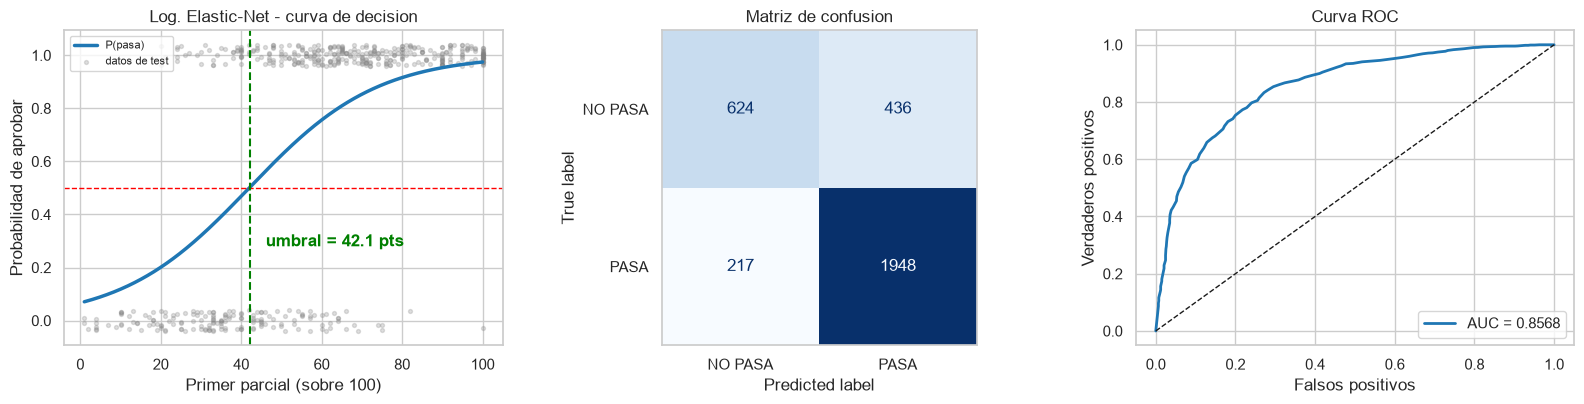

Con menos de 42.1 puntos en el primer parcial el modelo predice NO PASA.


,Primer.Par,P(pasa) %,Prediccion
0,10.0,11.8,NO PASA
1,20.0,20.1,NO PASA
2,30.0,32.0,NO PASA
3,40.0,46.9,NO PASA
4,50.0,62.3,PASA
5,60.0,75.6,PASA
6,70.0,85.3,PASA
7,80.0,91.6,PASA
8,90.0,95.3,PASA


In [20]:
# 3.1 ########## Graficos Regresion Logistica ##########
graficos_modelo("Log. Elastic-Net", log_reg, color="tab:blue")

# La curva sigmoide de arriba es la respuesta directa a la pregunta del parcial:
# muestra a partir de que puntaje del primer parcial la probabilidad de aprobar
# la materia supera el 50%.
u_log = umbral_aprobacion(log_reg)
print("Con menos de", u_log, "puntos en el primer parcial el modelo predice NO PASA.")

# Probabilidad estimada para algunos puntajes de referencia
ref = pd.DataFrame({"Primer.Par": [10.0, 20, 30, 40, 50, 60, 70, 80, 90]})
ref["P(pasa) %"] = (log_reg.predict_proba(ref[["Primer.Par"]])[:, 1] * 100).round(1)
ref["Prediccion"] = np.where(log_reg.predict(ref[["Primer.Par"]]) == 1, "PASA", "NO PASA")
ref


4. SVM LINEAL

Hiperplano: w*x + b = 0
Parametro C: controla el trade-off margen vs error
   - C chico  -> margen ancho, tolera mas errores (mas regularizacion)
   - C grande -> margen angosto, castiga cada error (menos regularizacion)

  C=   0.001 -> Accuracy: 0.7606
  C=   0.010 -> Accuracy: 0.7991
  C=   0.100 -> Accuracy: 0.7991
  C=   1.000 -> Accuracy: 0.8006
  C=  10.000 -> Accuracy: 0.8006
  C= 100.000 -> Accuracy: 0.8006
  C=1000.000 -> Accuracy: 0.8006

  Mejor C: 1.0
  Accuracy: 0.8006


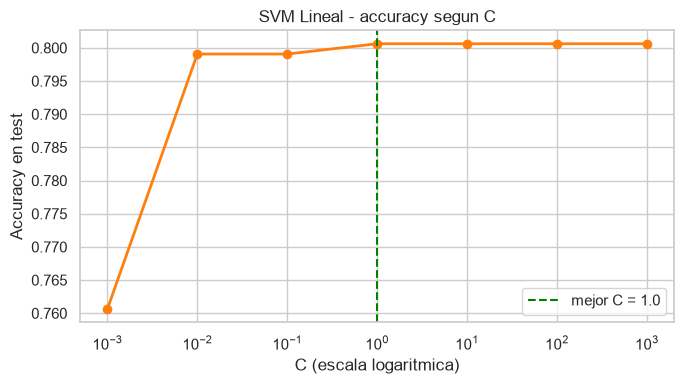

C:\Users\gatog\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Vectores de soporte: [3103 3102] ( total: 6205 )
Coeficiente (dato escalado): 1.3364
Intercepto : 0.822

=== SVM Lineal ===
              precision    recall  f1-score   support

     NO PASA       0.73      0.63      0.67      1060
        PASA       0.83      0.89      0.86      2165

    accuracy                           0.80      3225
   macro avg       0.78      0.76      0.76      3225
weighted avg       0.80      0.80      0.80      3225

ROC-AUC  : 0.8568
Umbral PP: 43.1 puntos


{'Accuracy': 0.8006201550387597,
 'Precision': 0.8285837651122625,
 'Recall': 0.8863741339491917,
 'F1': 0.8565052443650971,
 'ROC-AUC': 0.8568168547649135,
 'Umbral PP': 43.1}

In [21]:
# =============================================================================
# 4 ########## SVM ( Support Vector Machine ) - kernel LINEAL ##########
# =============================================================================
print("\n" + "=" * 80)
print("4. SVM LINEAL")
print("=" * 80)

print("\nHiperplano: w*x + b = 0")
print("Parametro C: controla el trade-off margen vs error")
print("   - C chico  -> margen ancho, tolera mas errores (mas regularizacion)")
print("   - C grande -> margen angosto, castiga cada error (menos regularizacion)")
print()

C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
svm_linear_results = []

for C in C_values:
    svm = SVC(kernel="linear", C=C, random_state=RANDOM_STATE)
    svm.fit(X_busq, y_busq)
    y_pred = svm.predict(X_test_scaled)
    score = accuracy_score(y_test, y_pred)
    svm_linear_results.append({
        "C": C,
        "accuracy": score,
        "n_vectores_soporte": int(svm.n_support_.sum()),
    })
    print(f"  C={C:8.3f} -> Accuracy: {score:.4f}")

df_svm_linear = pd.DataFrame(svm_linear_results)
best_C_linear = df_svm_linear.loc[df_svm_linear["accuracy"].idxmax(), "C"]
print(f"\n  Mejor C: {best_C_linear}")
print(f"  Accuracy: {df_svm_linear['accuracy'].max():.4f}")

# Accuracy en funcion de C (escala log en el eje x)
plt.figure(figsize=(7, 4))
plt.semilogx(df_svm_linear["C"], df_svm_linear["accuracy"],
             "o-", color="tab:orange", lw=2)
plt.axvline(best_C_linear, ls="--", c="green", lw=1.5,
            label=f"mejor C = {best_C_linear}")
plt.xlabel("C (escala logaritmica)")
plt.ylabel("Accuracy en test")
plt.title("SVM Lineal - accuracy segun C")
plt.legend()
plt.tight_layout()
plt.show()

# --- Modelo final: se reentrena con el mejor C sobre el train COMPLETO ------
# Se arma como Pipeline para que acepte el puntaje crudo 0-100 al predecir.
# probability=True habilita predict_proba (Platt scaling con CV interna),
# necesario para devolverle un porcentaje al usuario y para la curva ROC.
svm_lin = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="linear",
        C=best_C_linear,
        probability=True,
        cache_size=1000,
        random_state=RANDOM_STATE,
    )),
])

svm_lin.fit(X_train, y_train)

clf = svm_lin.named_steps["clf"]
print("Vectores de soporte:", clf.n_support_, "( total:", int(clf.n_support_.sum()), ")")
print("Coeficiente (dato escalado):", round(float(clf.coef_[0][0]), 4))
print("Intercepto :", round(float(clf.intercept_[0]), 4))
print()

evaluar("SVM Lineal", svm_lin)

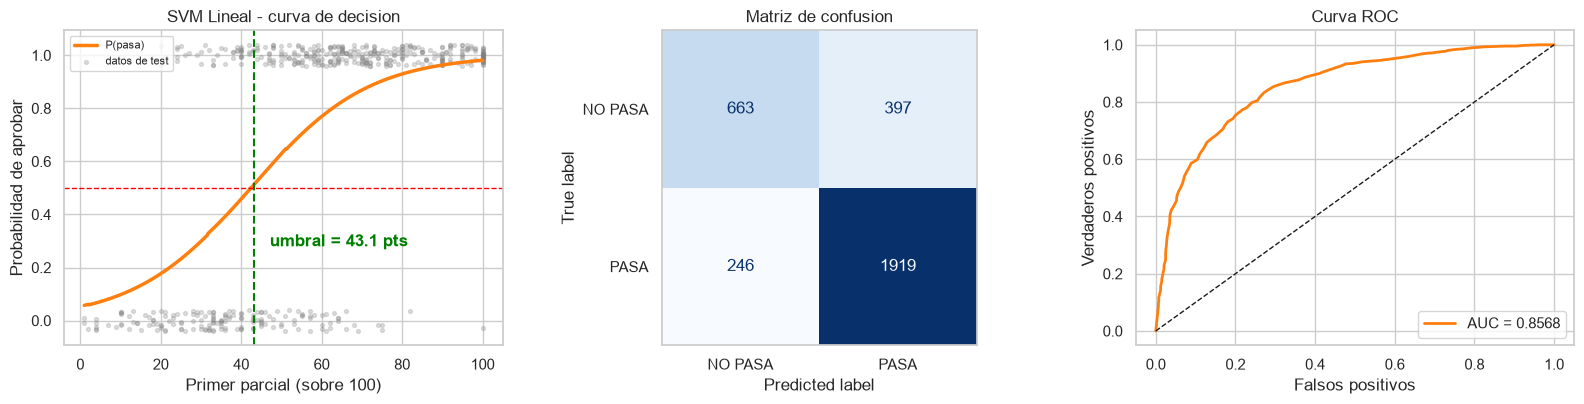

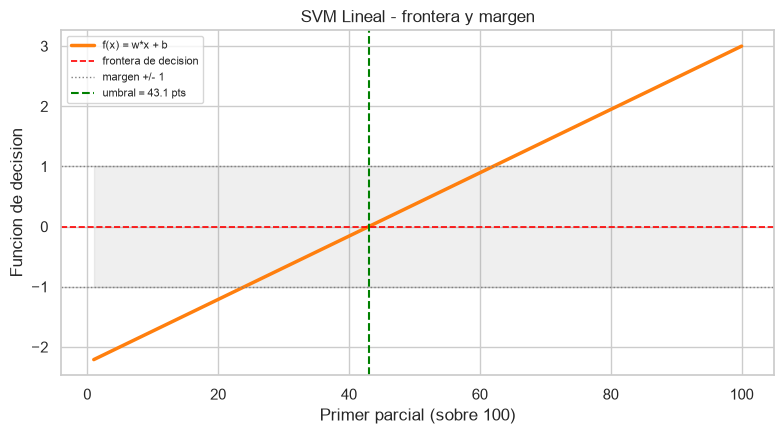

In [22]:
# 4.1 ########## Graficos SVM lineal ##########
graficos_modelo("SVM Lineal", svm_lin, color="tab:orange")

# Funcion de decision + margenes: la frontera esta donde f(x) = 0 y el margen
# del SVM es la banda entre f(x) = -1 y f(x) = +1.
dec = svm_lin.decision_function(GRID)
x_grid = GRID["Primer.Par"].values
u_lin = umbral_aprobacion(svm_lin)

plt.figure(figsize=(8, 4.5))
plt.plot(x_grid, dec, color="tab:orange", lw=2.5, label="f(x) = w*x + b")
plt.axhline(0, ls="--", c="red", lw=1.2, label="frontera de decision")
plt.axhline(1, ls=":", c="gray", lw=1)
plt.axhline(-1, ls=":", c="gray", lw=1, label="margen +/- 1")
plt.fill_between(x_grid, -1, 1, color="gray", alpha=0.12)
plt.axvline(u_lin, ls="--", c="green", lw=1.5, label="umbral = " + str(u_lin) + " pts")
plt.xlabel("Primer parcial (sobre 100)")
plt.ylabel("Funcion de decision")
plt.title("SVM Lineal - frontera y margen")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


5. SVM RBF (GAUSSIANO)

Kernel: K(x_i, x_j) = exp(-gamma * ||x_i - x_j||^2)
gamma: controla el alcance del kernel
   - gamma grande  -> decision local
   - gamma pequeno -> decision global

  C=  0.1, gamma= 0.001 -> Accuracy: 0.6713
  C=  0.1, gamma= 0.010 -> Accuracy: 0.7984
  C=  0.1, gamma= 0.100 -> Accuracy: 0.7978
  C=  0.1, gamma= 1.000 -> Accuracy: 0.7991
  C=  0.1, gamma=10.000 -> Accuracy: 0.7975
  C=  1.0, gamma= 0.001 -> Accuracy: 0.7984
  C=  1.0, gamma= 0.010 -> Accuracy: 0.7975
  C=  1.0, gamma= 0.100 -> Accuracy: 0.7981
  C=  1.0, gamma= 1.000 -> Accuracy: 0.7991
  C=  1.0, gamma=10.000 -> Accuracy: 0.7975
  C= 10.0, gamma= 0.001 -> Accuracy: 0.7991
  C= 10.0, gamma= 0.010 -> Accuracy: 0.7978
  C= 10.0, gamma= 0.100 -> Accuracy: 0.7975
  C= 10.0, gamma= 1.000 -> Accuracy: 0.7991
  C= 10.0, gamma=10.000 -> Accuracy: 0.7991
  C=100.0, gamma= 0.001 -> Accuracy: 0.7991
  C=100.0, gamma= 0.010 -> Accuracy: 0.7978
  C=100.0, gamma= 0.100 -> Accuracy: 0.7975
  C=100.0, gamma=

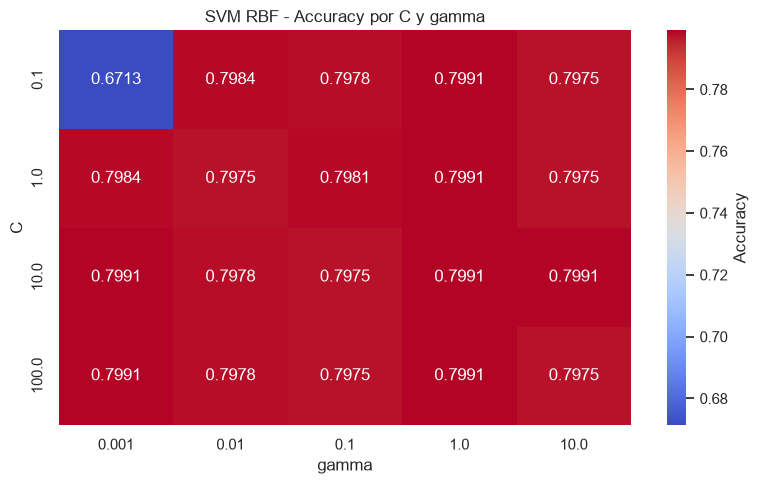

C:\Users\gatog\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Vectores de soporte: [2790 2790] ( total: 5580 )

=== SVM RBF ===
              precision    recall  f1-score   support

     NO PASA       0.74      0.60      0.66      1060
        PASA       0.82      0.89      0.86      2165

    accuracy                           0.80      3225
   macro avg       0.78      0.75      0.76      3225
weighted avg       0.79      0.80      0.79      3225

ROC-AUC  : 0.7992
Umbral PP: 42.9 puntos


{'Accuracy': 0.7990697674418604,
 'Precision': 0.8220806794055202,
 'Recall': 0.8942263279445728,
 'F1': 0.856637168141593,
 'ROC-AUC': 0.7992195738376399,
 'Umbral PP': 42.9}

In [23]:
# =============================================================================
# 5 ########## SVM - kernel RBF (GAUSSIANO) ##########
# =============================================================================
print("\n" + "=" * 80)
print("5. SVM RBF (GAUSSIANO)")
print("=" * 80)

print("\nKernel: K(x_i, x_j) = exp(-gamma * ||x_i - x_j||^2)")
print("gamma: controla el alcance del kernel")
print("   - gamma grande  -> decision local")
print("   - gamma pequeno -> decision global")
print()

C_values = [0.1, 1, 10, 100]
gamma_values = [0.001, 0.01, 0.1, 1, 10]

svm_rbf_results = []
for C in C_values:
    for gamma in gamma_values:
        svm = SVC(kernel="rbf", C=C, gamma=gamma, random_state=RANDOM_STATE)
        svm.fit(X_busq, y_busq)
        y_pred = svm.predict(X_test_scaled)

        score = accuracy_score(y_test, y_pred)
        svm_rbf_results.append({
            "C": C,
            "gamma": gamma,
            "accuracy": score,
        })
        print(f"  C={C:5.1f}, gamma={gamma:6.3f} -> Accuracy: {score:.4f}")

df_svm_rbf = pd.DataFrame(svm_rbf_results)
best_svm = df_svm_rbf.loc[df_svm_rbf["accuracy"].idxmax()]
print(f"\n  Mejor combinacion: C={best_svm['C']:.1f}, gamma={best_svm['gamma']:.3f}")
print(f"     Accuracy: {best_svm['accuracy']:.4f}")

# Visualizacion: heatmap de resultados
pivot_svm = df_svm_rbf.pivot(index="C", columns="gamma", values="accuracy")
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_svm, annot=True, cmap="coolwarm", fmt=".4f",
            cbar_kws={"label": "Accuracy"})
plt.title("SVM RBF - Accuracy por C y gamma")
plt.xlabel("gamma")
plt.ylabel("C")
plt.tight_layout()
plt.show()

# --- Modelo final: mejor combinacion sobre el train COMPLETO ---------------
svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="rbf",
        C=float(best_svm["C"]),
        gamma=float(best_svm["gamma"]),
        probability=True,
        cache_size=1000,
        random_state=RANDOM_STATE,
    )),
])

svm_rbf.fit(X_train, y_train)   # puede tardar un rato por probability=True

clf = svm_rbf.named_steps["clf"]
print("Vectores de soporte:", clf.n_support_, "( total:", int(clf.n_support_.sum()), ")")
print()

evaluar("SVM RBF", svm_rbf)

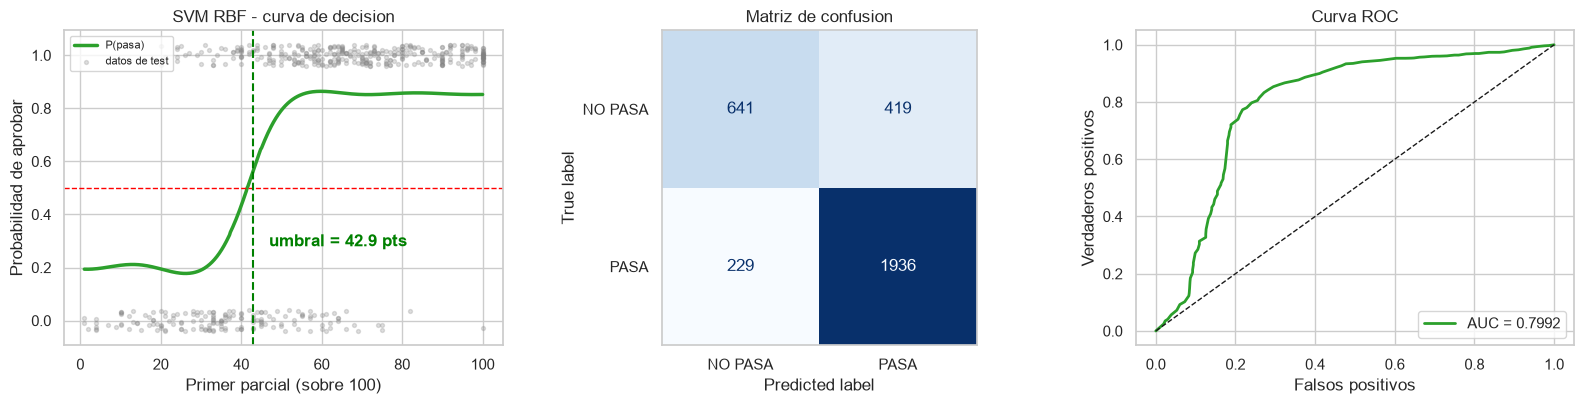

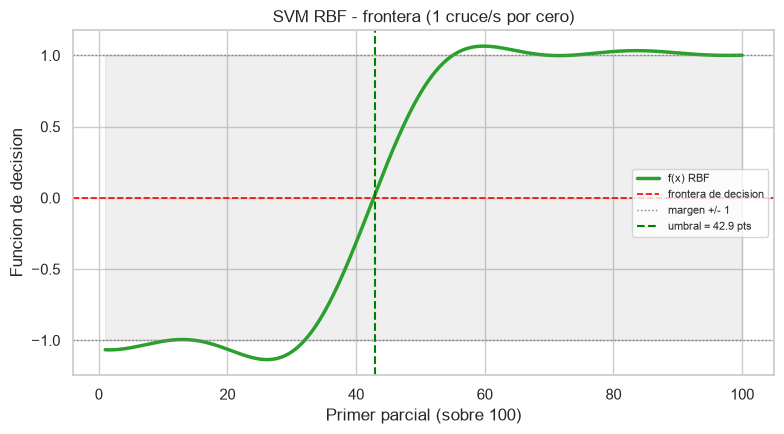

In [24]:
# 5.1 ########## Graficos SVM RBF ##########
graficos_modelo("SVM RBF", svm_rbf, color="tab:green")

# Funcion de decision del RBF: si la curva cruza el cero mas de una vez, la
# frontera es realmente no lineal; si lo cruza una sola vez, el RBF termina
# comportandose como un umbral simple igual que el modelo lineal.
dec = svm_rbf.decision_function(GRID)
x_grid = GRID["Primer.Par"].values
cruces = int(np.sum(np.diff(np.sign(dec)) != 0))
u_rbf = umbral_aprobacion(svm_rbf)

plt.figure(figsize=(8, 4.5))
plt.plot(x_grid, dec, color="tab:green", lw=2.5, label="f(x) RBF")
plt.axhline(0, ls="--", c="red", lw=1.2, label="frontera de decision")
plt.axhline(1, ls=":", c="gray", lw=1)
plt.axhline(-1, ls=":", c="gray", lw=1, label="margen +/- 1")
plt.fill_between(x_grid, -1, 1, color="gray", alpha=0.12)
plt.axvline(u_rbf, ls="--", c="green", lw=1.5, label="umbral = " + str(u_rbf) + " pts")
plt.xlabel("Primer parcial (sobre 100)")
plt.ylabel("Funcion de decision")
plt.title("SVM RBF - frontera (" + str(cruces) + " cruce/s por cero)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [25]:
# 6 ########## Comparaciones ##########
df_comp = pd.DataFrame(resultados).T
df_comp = df_comp[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "Umbral PP"]]
df_comp = df_comp.sort_values("F1", ascending=False)

# "Umbral PP" = puntaje minimo del primer parcial a partir del cual cada modelo
# predice que el alumno aprueba la materia. Es la respuesta concreta a la
# pregunta del parcial.
df_comp.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC,Umbral PP
SVM RBF,0.7991,0.8221,0.8942,0.8566,0.7992,42.9
SVM Lineal,0.8006,0.8286,0.8864,0.8565,0.8568,43.1
Log. Elastic-Net,0.7975,0.8171,0.8998,0.8565,0.8568,42.1


In [26]:
# 6.1 ########## Tabla de comparaciones ##########
tabla = df_comp.round(4)
met = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

print("TABLA COMPARATIVA (metricas sobre el 20% de test)")
print()
print(tabla.to_string())
print()
print("Mejor modelo por F1 :", tabla["F1"].idxmax())
print("Mejor modelo por AUC:", tabla["ROC-AUC"].idxmax())
print()
print("Umbral de aprobacion segun cada modelo:")
for nombre, fila in tabla.iterrows():
    print("  -", nombre.ljust(18), "->", fila["Umbral PP"], "puntos")

# Version con colores (requiere jinja2; si no esta, muestra la tabla simple)
try:
    salida_tabla = tabla.style.background_gradient(cmap="Greens", subset=met)                               .format("{:.4f}", subset=met)
except (ImportError, AttributeError):
    salida_tabla = tabla

salida_tabla

TABLA COMPARATIVA (metricas sobre el 20% de test)

                  Accuracy  Precision  Recall      F1  ROC-AUC  Umbral PP
SVM RBF             0.7991     0.8221  0.8942  0.8566   0.7992       42.9
SVM Lineal          0.8006     0.8286  0.8864  0.8565   0.8568       43.1
Log. Elastic-Net    0.7975     0.8171  0.8998  0.8565   0.8568       42.1

Mejor modelo por F1 : SVM RBF
Mejor modelo por AUC: SVM Lineal

Umbral de aprobacion segun cada modelo:
  - SVM RBF            -> 42.9 puntos
  - SVM Lineal         -> 43.1 puntos
  - Log. Elastic-Net   -> 42.1 puntos


,Accuracy,Precision,Recall,F1,ROC-AUC,Umbral PP
SVM RBF,0.7991,0.8221,0.8942,0.8566,0.7992,42.900000
SVM Lineal,0.8006,0.8286,0.8864,0.8565,0.8568,43.100000
Log. Elastic-Net,0.7975,0.8171,0.8998,0.8565,0.8568,42.100000


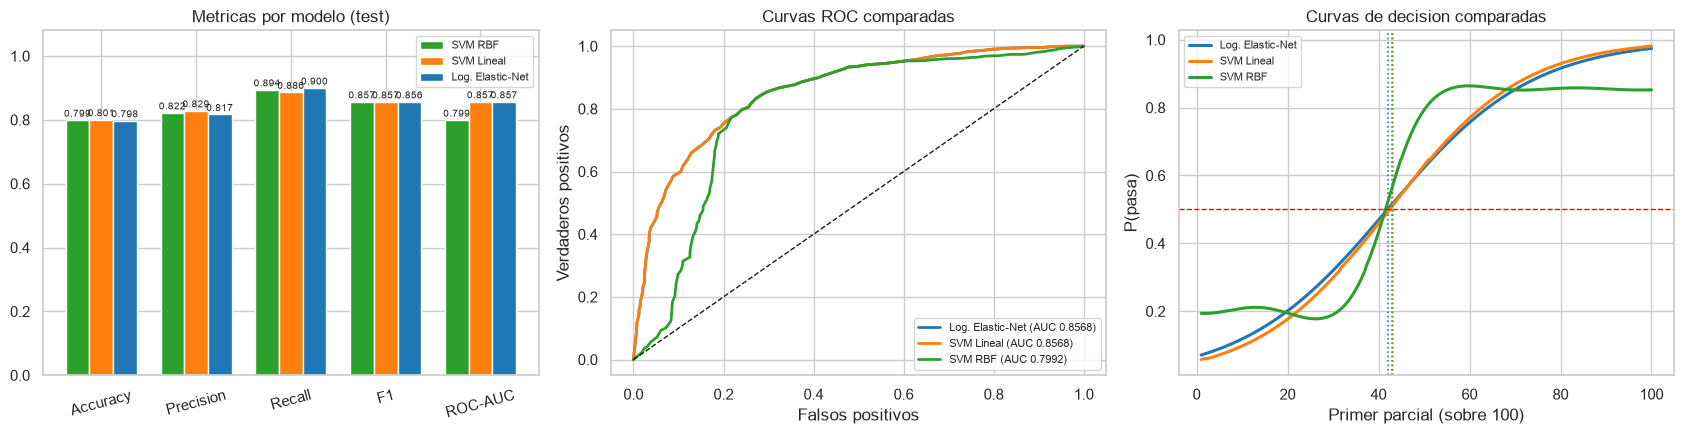

In [27]:
# 6.2 ########## Graficos de comparaciones ##########
colores = {"Log. Elastic-Net": "tab:blue", "SVM Lineal": "tab:orange", "SVM RBF": "tab:green"}
metricas = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))

# (a) barras agrupadas de metricas
ancho = 0.25
pos = np.arange(len(metricas))
for i, nombre in enumerate(df_comp.index):
    valores = df_comp.loc[nombre, metricas].values.astype(float)
    barras = ax[0].bar(pos + i * ancho, valores, ancho,
                       label=nombre, color=colores.get(nombre))
    ax[0].bar_label(barras, fmt="%.3f", fontsize=7, padding=1)
ax[0].set_xticks(pos + ancho)
ax[0].set_xticklabels(metricas, rotation=15)
ax[0].set_ylim(0, 1.08)
ax[0].set_title("Metricas por modelo (test)")
ax[0].legend(fontsize=8)

# (b) las 3 curvas ROC superpuestas
for nombre, modelo in modelos.items():
    y_prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax[1].plot(fpr, tpr, lw=2, color=colores.get(nombre),
               label=nombre + " (AUC " + str(round(auc, 4)) + ")")
ax[1].plot([0, 1], [0, 1], "k--", lw=1)
ax[1].set_xlabel("Falsos positivos")
ax[1].set_ylabel("Verdaderos positivos")
ax[1].set_title("Curvas ROC comparadas")
ax[1].legend(loc="lower right", fontsize=8)

# (c) las 3 curvas de probabilidad sobre el mismo eje
for nombre, modelo in modelos.items():
    ax[2].plot(GRID["Primer.Par"], modelo.predict_proba(GRID)[:, 1],
               lw=2.2, color=colores.get(nombre), label=nombre)
    ax[2].axvline(umbral_aprobacion(modelo), ls=":", lw=1.2, color=colores.get(nombre))
ax[2].axhline(0.5, ls="--", c="red", lw=1)
ax[2].set_xlabel("Primer parcial (sobre 100)")
ax[2].set_ylabel("P(pasa)")
ax[2].set_title("Curvas de decision comparadas")
ax[2].legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

In [28]:
# 7 ########## Prediccion interactiva ##########

def predecir(puntaje, mostrar=True):
    """Recibe el puntaje del primer parcial (0 a 100) y responde PASA / NO PASA
    con los tres modelos entrenados."""
    if not (0 <= puntaje <= 100):
        raise ValueError("El puntaje debe estar entre 0 y 100.")

    entrada = pd.DataFrame({"Primer.Par": [float(puntaje)]})
    filas = []
    for nombre, modelo in modelos.items():
        p = float(modelo.predict_proba(entrada)[0, 1])
        filas.append({
            "Modelo": nombre,
            "P(pasa) %": round(p * 100, 1),
            "Resultado": "PASA" if modelo.predict(entrada)[0] == 1 else "NO PASA",
        })

    salida = pd.DataFrame(filas).set_index("Modelo")
    if mostrar:
        print("Primer parcial:", puntaje, "/ 100")
        print(salida.to_string())
        print()
    return salida


# --- ejemplos (no bloquean la ejecucion del notebook) -----------------------
for pts in [10, 30, 45, 50, 60, 85]:
    predecir(pts)

Primer parcial: 10 / 100
                  P(pasa) % Resultado
Modelo                               
Log. Elastic-Net       11.8   NO PASA
SVM Lineal              9.8   NO PASA
SVM RBF                20.8   NO PASA

Primer parcial: 30 / 100
                  P(pasa) % Resultado
Modelo                               
Log. Elastic-Net       32.0   NO PASA
SVM Lineal             29.9   NO PASA
SVM RBF                19.0   NO PASA

Primer parcial: 45 / 100
                  P(pasa) % Resultado
Modelo                               
Log. Elastic-Net       54.7      PASA
SVM Lineal             54.4      PASA
SVM RBF                64.8      PASA

Primer parcial: 50 / 100
                  P(pasa) % Resultado
Modelo                               
Log. Elastic-Net       62.3      PASA
SVM Lineal             62.9      PASA
SVM RBF                79.3      PASA

Primer parcial: 60 / 100
                  P(pasa) % Resultado
Modelo                               
Log. Elastic-Net       75.6      PA

In [29]:
# 7.1 ########## Entrada por teclado (descomentar para usar) ##########
# puntaje = float(input("Ingrese su puntaje del primer parcial (0-100): "))
# predecir(puntaje)

## Conclusiones

- La separacion 80/20 estratificada permite medir el rendimiento sobre datos que
  el modelo nunca vio durante el entrenamiento.
- Se usa un **unico feature** (`Primer.Par`), asi que los tres modelos terminan
  aprendiendo esencialmente el mismo umbral y sus metricas son muy parecidas.
  Eso no es un error: con una sola variable no hay una frontera "no lineal" que
  el kernel RBF pueda aprovechar mas alla de un corte.
- **Respuesta a la pregunta:** ver la columna `Umbral PP` de la tabla comparativa.
  Por debajo de ese puntaje los modelos predicen que el alumno **no** remonta.
  Aun asi la probabilidad es gradual: cerca del umbral el pronostico es incierto,
  y el resultado real depende de factores que este modelo no ve (segundo parcial,
  laboratorio, asistencia, recuperatorios).
